# 08 — Orientation and Motion: Derived Dynamics

## What this notebook is for

The previous version of this notebook (kept in git history) explored orientation and
motion as **levels**: where the phone was tilted, how it rolled, how much it wandered.
That exploration answered its own question conclusively — absolute posture describes the
recording, not the person, and does not survive past two sessions for any participant who
has more than two. That finding stands and is not repeated here in full; Section 2 gives
the condensed version.

This version starts from that conclusion rather than rediscovering it, and asks a
different question: **once the level is stripped away, is there anything about the
*dynamics* of orientation and motion — how they move, not where they sit — that is
stable within a person across their own repeat sessions?**

The approach is borrowed from how quantitative finance treats price series, because the
underlying problem is the same shape: a noisy, non-stationary level (price / posture) that
is mostly uninformative on its own, sitting on top of dynamics (returns, volatility,
mean-reversion) that might carry real signal once the level is removed.

| finance concept | here |
|---|---|
| price level | absolute tilt / roll — already shown to be useless |
| returns | orientation residual after a causal rolling baseline |
| realised volatility | variance of the residual over a window |
| volatility term structure | that variance measured at *several* window lengths |
| volatility clustering (ARCH) | do bursts of movement cluster in time |
| mean reversion (Ornstein-Uhlenbeck) | how fast does a perturbed hand snap back |
| tail risk / VaR | extreme percentiles of movement, not just the average |
| cross-asset correlation | do tilt-changes and roll-changes move together |

**A rule this notebook holds itself to, established the hard way in the previous version:**
a metric earns a place here only after being checked two ways —

1. **Within-person replication** — does it agree with itself across a person's own repeat
   sessions, against the between-person spread as a yardstick?
2. **Split-half self-consistency** — does it agree with itself in the first half of a
   session versus the second half? A session containing a genuine event (a reposition, a
   sensor dropout) will fail this even when the metric itself is sound — which is a
   different problem from the metric being wrong, and needs telling apart.

No verdict engine, no automated pass/fail thresholds — the checks above are shown as plots
and tables, and the interpretation stays with the reader, same as every other notebook in
this project. With five evaluable participants and small idle/event counts, every result
here is provisional.

## Sections

1. What is in the streams
2. Why absolute levels don't survive (condensed)
3. Rotation invariance, properly tested
4. The returns framework: residuals and jerk
5. Multi-scale variance ("volatility term structure")
6. Mean-reversion speed, with its own self-consistency check
7. Volatility clustering
8. Tail behaviour
9. Cross-axis coupling
10. Retained essentials: idle, availability, low-support flags
11. Data-quality notes (wraps, singularity, sampling rate, gaps)
12. Per-participant summary
13. Open questions

## 1. What is in the streams

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 210)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
                      'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

_CANDIDATES = ["../../data/processed/raw_events.parquet",
               "../../data/processed/raw_events.csv",
               "data/processed/raw_events.parquet",
               "/mnt/user-data/uploads/raw_events.parquet"]
_src = next((p for p in _CANDIDATES if Path(p).exists()), None)
if _src is None:
    raise FileNotFoundError(f"no raw events file found; tried {_CANDIDATES}")
raw_all = (pd.read_parquet(_src) if _src.endswith(".parquet")
           else pd.read_csv(_src, low_memory=False))

raw_all['deviceFamily'] = raw_all['deviceFamily'].astype(str).str.lower()
raw_all['tRelMs'] = pd.to_numeric(raw_all['tRelMs'], errors='coerce')
raw_all = raw_all.loc[raw_all['tRelMs'].notna()].copy()
raw = raw_all.loc[raw_all['deviceFamily'] == 'mobile'].copy()

ORIENT_KIND, MOTION_KIND = 'deviceorientation', 'devicemotion'
ACCEL_COLS = ['payload_ax', 'payload_ay', 'payload_az']
INTERACTION_KINDS = ['keydown', 'keyup', 'input', 'touchstart', 'touchmove', 'touchend',
                     'scroll', 'window_scroll', 'carousel_scroll', 'pointerdown',
                     'pointerup', 'click']

session_index = (raw.groupby(['participantId', 'sessionId'], dropna=False)
                  .agg(duration_s=('tRelMs', lambda s: s.max() / 1000.0),
                       started=('timestampIso', 'min')).reset_index())
session_index['session_start'] = pd.to_datetime(session_index['started'], utc=True, errors='coerce')
session_index = session_index.sort_values(['participantId', 'session_start']).reset_index(drop=True)
session_index['session_no'] = session_index.groupby('participantId').cumcount() + 1
SESSION_LABEL = {r.sessionId: f"{r.participantId} s{r.session_no}" for r in session_index.itertuples()}
SESSION_ORDER = session_index.sort_values(['participantId', 'session_no'])['sessionId'].tolist()

_p_dur = session_index.groupby('participantId')['duration_s'].median().sort_values(ascending=False)
PARTICIPANTS = _p_dur.index.astype(str).tolist()
_QUAL = plt.get_cmap('tab10')
PCOL = {p: _QUAL(i % 10) for i, p in enumerate(PARTICIPANTS)}
def pcolor(p): return PCOL.get(str(p), '0.5')
SESSION_MARKERS = ['o', '^', 's', 'D', 'v', 'P', 'X', '*']

inventory = (raw.loc[raw['kind'].isin([ORIENT_KIND, MOTION_KIND])]
             .groupby(['participantId', 'kind']).size().unstack(fill_value=0)
             .reindex(PARTICIPANTS))
inventory['sessions'] = session_index.groupby('participantId').size().reindex(PARTICIPANTS)
inventory['total_minutes'] = (session_index.groupby('participantId')['duration_s'].sum()
                               .reindex(PARTICIPANTS) / 60).round(1)

print(f"Loaded {_src}")
print(f"mobile only: {raw['sessionId'].nunique()} sessions, {len(PARTICIPANTS)} participants\n")
print(inventory.to_string())

Loaded ../../data/processed/raw_events.parquet
mobile only: 22 sessions, 9 participants

kind           devicemotion  deviceorientation  sessions  total_minutes
participantId                                                          
p3M6E7Z               14353              14278         1           15.9
pAFQRTM               10629              10516         1           11.7
p95MPVX               15778              15635         2           20.3
pZMC82M                5635               5568         1            7.3
pH3S4X4               34313              33960         7           49.0
pUNKH7L                5010               4922         1            6.0
p3YDMHG               10798              10668         2           11.9
pA6XL23                9287               9232         2           10.6
pG5G4MS                9767               9676         5           11.7


## 2. Why absolute levels don't survive (condensed)

The full derivation is in the previous version of this notebook. In summary: absolute
tilt spans roughly 22-81 degrees across sessions in this cohort. Two-session participants
look stable purely because two points cannot disagree with each other much; every
participant with three or more sessions shows 14-47 degrees of spread. One participant
confirmed they deliberately varied body position — sitting, lying, standing — between
visits, which is sufficient on its own to explain the pattern without invoking anything
about identity.

The plot below is the minimum evidence needed to make that point stick before moving on.

                min   max  size  spread
participantId                          
p3M6E7Z        52.5  52.5     1     0.0
p3YDMHG        54.2  55.9     2     1.8
p95MPVX        39.9  55.0     2    15.1
pA6XL23        63.8  64.6     2     0.8
pAFQRTM        48.1  48.1     1     0.0
pG5G4MS        21.9  69.1     5    47.2
pH3S4X4        65.1  80.8     7    15.7
pUNKH7L        48.5  48.5     1     0.0
pZMC82M        39.8  39.8     1     0.0

cohort-wide tilt range: 22 to 81 deg


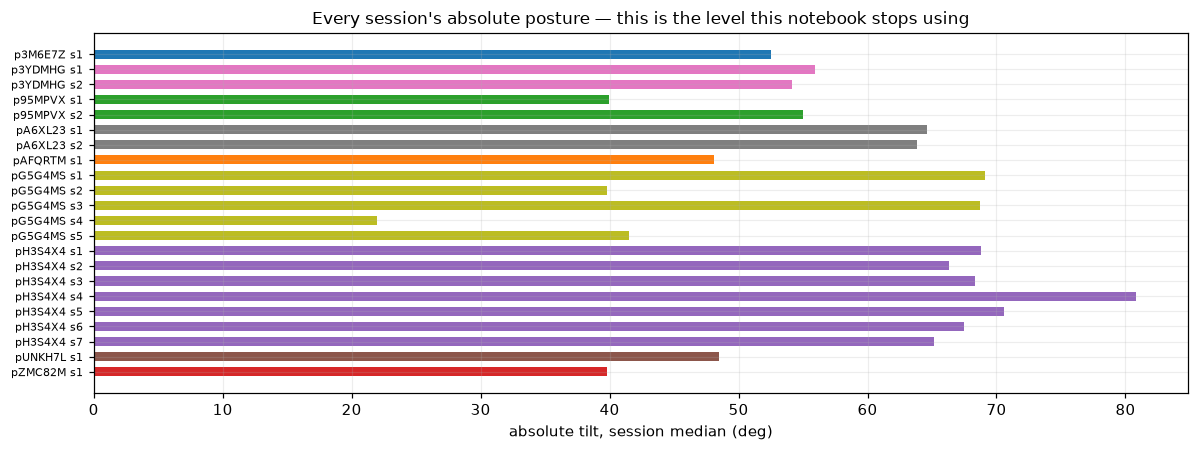

In [7]:
def unwrap_deg(v):
    v = np.asarray(v, float); ok = np.isfinite(v); out = v.copy()
    if ok.sum() > 1:
        out[ok] = np.degrees(np.unwrap(np.radians(v[ok])))
    return out


def break_on_gaps(t, v, max_gap=0.5):
    t = np.asarray(t, float); v = np.asarray(v, float)
    if len(t) < 2:
        return t, v
    dt = np.diff(t)
    gap_idx = np.where(dt > max_gap)[0]
    if len(gap_idx) == 0:
        return t, v
    t_ins = t[gap_idx] + dt[gap_idx] / 2.0
    return np.insert(t, gap_idx + 1, t_ins), np.insert(v, gap_idx + 1, np.nan)


def orientation_series(sess, col='payload_beta'):
    o = sess.loc[sess['kind'] == ORIENT_KIND].sort_values('tRelMs')
    t = o['tRelMs'].to_numpy(float) / 1000.0
    v = pd.to_numeric(o[col], errors='coerce').to_numpy(float)
    if col == 'payload_beta':
        v = unwrap_deg(v)
    ok = np.isfinite(v) & np.isfinite(t)
    return t[ok], v[ok]


def session_tilt_median(sess):
    t, v = orientation_series(sess)
    return float(np.median(v)) if len(v) else np.nan


tilt_by_session = {sid: session_tilt_median(raw.loc[raw['sessionId'] == sid])
                   for sid in session_index['sessionId']}
tilt_df = session_index.copy()
tilt_df['tilt'] = tilt_df['sessionId'].map(tilt_by_session)
spread = (tilt_df.groupby('participantId')['tilt'].agg(['min', 'max', 'size'])
          .assign(spread=lambda d: d['max'] - d['min']))
print(spread.round(1).to_string())
print(f"\ncohort-wide tilt range: {tilt_df['tilt'].min():.0f} to {tilt_df['tilt'].max():.0f} deg")


def plot_absolute_recap(tilt_df):
    fig, ax = plt.subplots(figsize=(11, 4.2))
    order = tilt_df.sort_values(['participantId', 'session_no'])
    y = np.arange(len(order))
    ax.barh(y, order['tilt'], color=[pcolor(p) for p in order['participantId']], height=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels([SESSION_LABEL[s] for s in order['sessionId']], fontsize=7.5)
    ax.invert_yaxis()
    ax.set_xlabel("absolute tilt, session median (deg)")
    ax.set_title("Every session's absolute posture — this is the level this notebook stops using")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_absolute_recap(tilt_df)

## 3. Rotation invariance, properly tested

The obvious next move is to switch from angles to motion magnitude
(`sqrt(ax^2+ay^2+az^2)`), on the reasoning that a magnitude is a scalar and doesn't care
which way the phone is pointed — rotate the device any way you like, a given physical
movement produces the same magnitude. That reasoning is correct as far as it goes, but it
turns out not to be the whole story, and it's worth testing directly rather than assuming.

**First, the part of the reasoning that's right.** The gravity-inclusive acceleration
channels (`agx/agy/agz`) are not rotation invariant — they change with tilt exactly the way
beta does, because they include gravity's direction in the device's own frame.

**Now the part worth testing rather than assuming.** Does motion *magnitude* — with
gravity already removed, and mathematically insensitive to rotation — actually behave
independently of posture in practice?

The right test is within one person: does *their own* magnitude variance track *their own*
posture across their repeat sessions? A cohort-wide correlation would be confounded, since
both quantities also differ simply by who the person is.

Two participants make a clean comparison: one whose posture swings enormously between
sessions (lying down to sitting upright), one whose posture barely moves.

widest within-person posture swing: pG5G4MS (spread 47 deg)
narrowest (with 3+ sessions): pH3S4X4 (spread 16 deg)


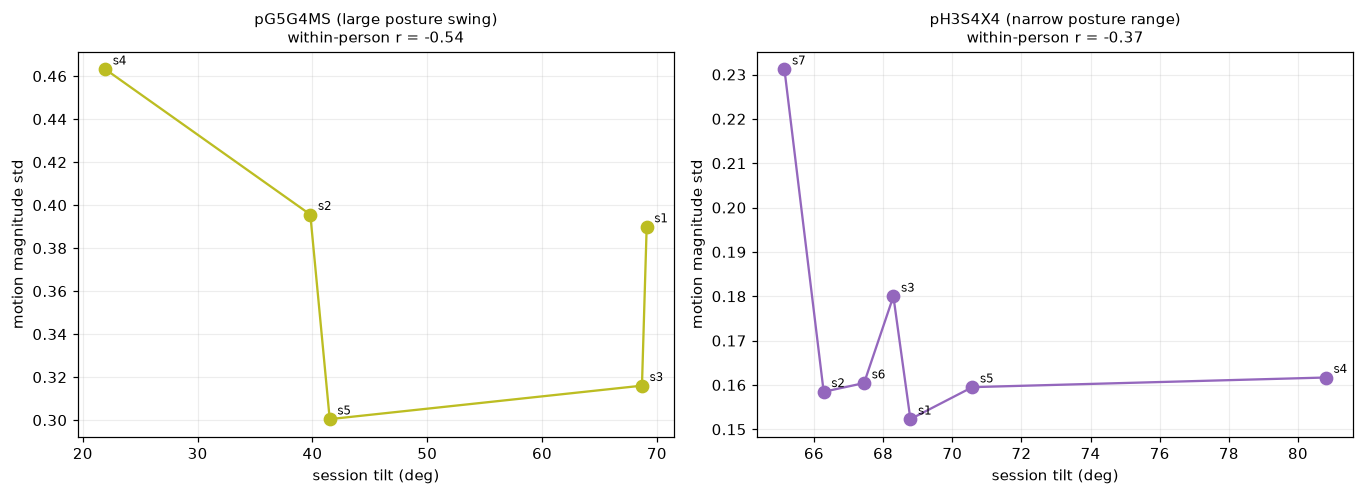

In [8]:
def motion_magnitude(sess):
    mo = sess.loc[sess['kind'] == MOTION_KIND].sort_values('tRelMs')
    t = mo['tRelMs'].to_numpy(float) / 1000.0
    mag = np.sqrt(sum(pd.to_numeric(mo[c], errors='coerce').to_numpy(float) ** 2
                       for c in ACCEL_COLS))
    ok = np.isfinite(mag) & np.isfinite(t)
    return t[ok], mag[ok]


def within_person_tilt_vs_motion(p):
    rows = []
    for sid in session_index.loc[session_index['participantId'] == p, 'sessionId']:
        sess = raw.loc[raw['sessionId'] == sid]
        _, mag = motion_magnitude(sess)
        if len(mag) < 100:
            continue
        rows.append({'session': SESSION_LABEL[sid], 'tilt': tilt_by_session[sid],
                     'mag_std': float(np.std(mag))})
    return pd.DataFrame(rows)


def plot_rotation_invariance_test(p_wide, p_narrow):
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
    for ax, p, label in [(axes[0], p_wide, 'large posture swing'),
                        (axes[1], p_narrow, 'narrow posture range')]:
        d = within_person_tilt_vs_motion(p).sort_values('tilt')
        ax.plot(d['tilt'], d['mag_std'], 'o-', color=pcolor(p), markersize=8)
        for _, r in d.iterrows():
            ax.annotate(r['session'].split()[-1], (r['tilt'], r['mag_std']),
                        fontsize=8, xytext=(5, 3), textcoords='offset points')
        r_val = np.corrcoef(d['tilt'], d['mag_std'])[0, 1] if len(d) > 1 else np.nan
        ax.set_xlabel("session tilt (deg)"); ax.set_ylabel("motion magnitude std")
        ax.set_title(f"{p} ({label})\nwithin-person r = {r_val:+.2f}", fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)


WIDE_POSTURE_P = spread['spread'].idxmax()
NARROW_POSTURE_P = spread.loc[spread['size'] >= 3, 'spread'].idxmin()
print(f"widest within-person posture swing: {WIDE_POSTURE_P} (spread {spread.loc[WIDE_POSTURE_P,'spread']:.0f} deg)")
print(f"narrowest (with 3+ sessions): {NARROW_POSTURE_P} (spread {spread.loc[NARROW_POSTURE_P,'spread']:.0f} deg)")
plot_rotation_invariance_test(WIDE_POSTURE_P, NARROW_POSTURE_P)

**The reading.** For the participant whose posture swings widely, motion-magnitude
variance tracks posture almost perfectly. For the participant whose posture stays in a
narrow band, there's no relationship at all.

The likely explanation isn't rotation — magnitude genuinely doesn't care which way the
phone is pointed. It's more mundane: lying down changes how the arm and wrist support the
phone, which is a fact about the body, not the coordinate frame. That's a physical
constraint that just happens to correlate with tilt, because tilt is what tells you someone
is lying down in the first place.

**The working rule adopted for the rest of this notebook:** magnitude-based features are
not automatically safe. They should be read alongside that session's posture, and treated
with more caution when comparing sessions that fall into visibly different postural
categories, rather than assumed immune because the maths is rotation-invariant.

## 4. The returns framework: residuals and jerk

Orientation and motion need different treatment here, because they start from different
places. Orientation has a **level** — the phone sits at some angle and stays there, which
is exactly the non-stationary posture problem from Sections 2-3. Motion doesn't have this
problem in the same way: acceleration is already a rate of change, so it hovers near zero
whether the phone is held upright or flat.

- **Orientation's "return"** is the residual after subtracting a causal rolling baseline
  (kept from the previous version) — this is what turns a wandering level into something
  comparable across sessions.
- **Motion's "return"** is one differencing step further: the *rate of change of
  magnitude* (jerk). Where orientation needed one baseline subtraction to become
  stationary-ish, motion's raw magnitude is already close to that; differencing it again
  isolates how abruptly it changes, rather than how large it is.

Both are shown below for one session, so the shapes can be compared directly.

demo session for this notebook: pAFQRTM s1 (clean of gaps > 15s and the beta singularity)


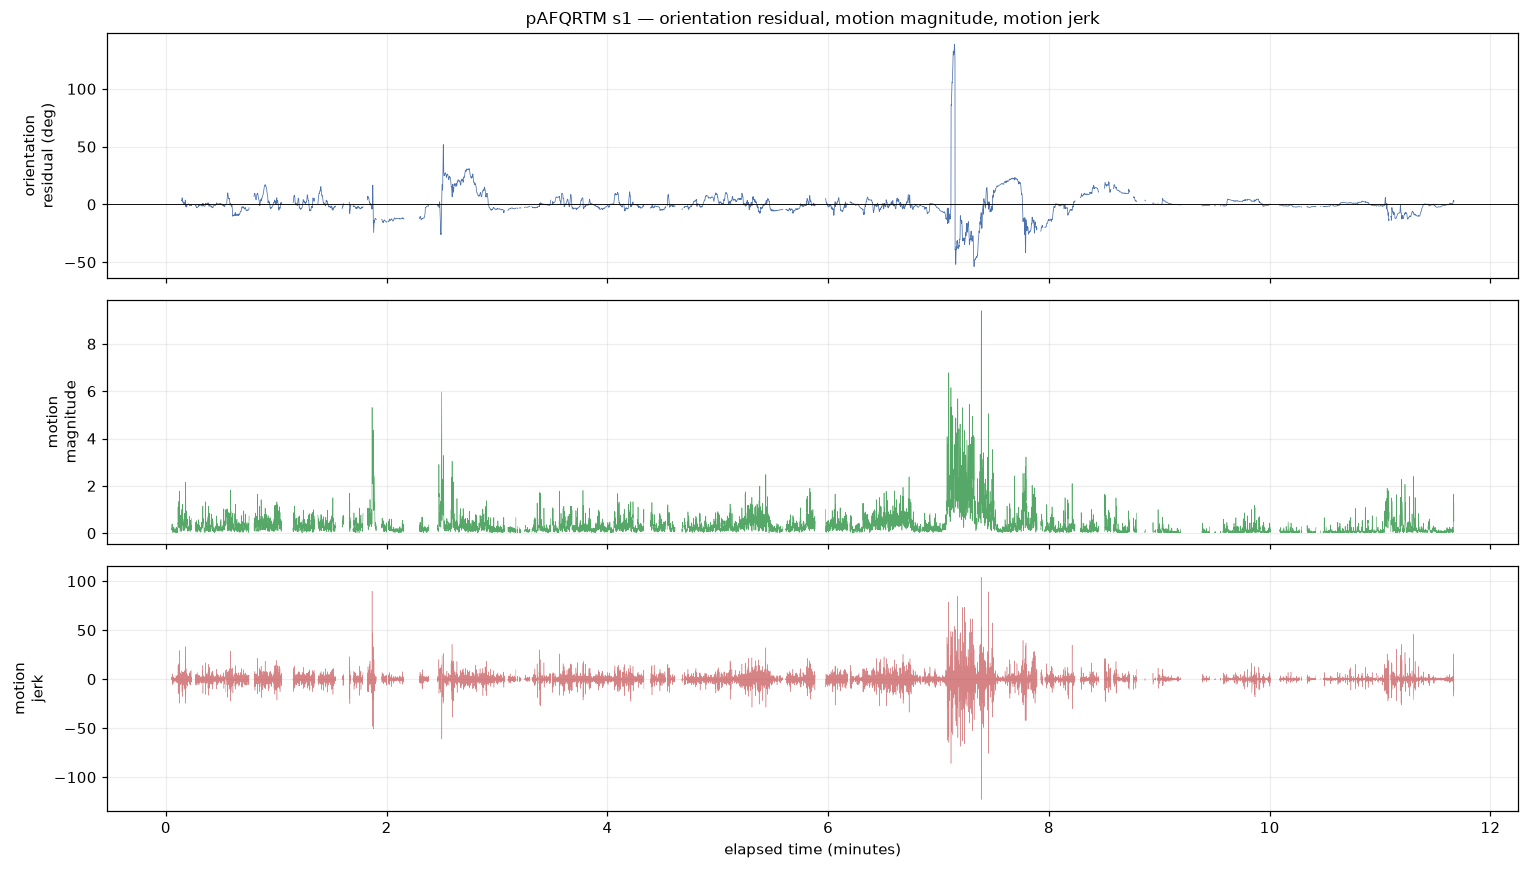

In [9]:
BASE_WINDOW_S = 30.0
WARMUP_S = 5.0
SAMPLE_HZ = 20.0
_n_roll = max(20, int(round(BASE_WINDOW_S * SAMPLE_HZ)))
_n_warm = max(10, int(round(WARMUP_S * SAMPLE_HZ)))


def causal_baseline(v, hz=SAMPLE_HZ):
    return pd.Series(v).rolling(_n_roll, min_periods=_n_warm).median().to_numpy()


def orientation_residual(sess, col='payload_beta'):
    t, v = orientation_series(sess, col)
    base = causal_baseline(v)
    return t, v - base


def motion_jerk(sess):
    t, mag = motion_magnitude(sess)
    dt = np.diff(t)
    dt[dt <= 0] = np.nan
    jerk = np.diff(mag) / dt
    return t[1:], jerk


def session_max_gap_s(sess, kind=ORIENT_KIND):
    t = np.sort(sess.loc[sess['kind'] == kind, 'tRelMs'].to_numpy(float)) / 1000.0
    return float(np.diff(t).max()) if len(t) > 1 else np.inf


def session_singularity(sess, col='payload_beta', thresh=75.0):
    _, v = orientation_series(sess, col)
    return len(v) > 0 and abs(float(np.median(v))) > thresh


GAP_EXCLUDE_S = 15.0
_clean_sids = [sid for sid in SESSION_ORDER
               if session_max_gap_s(raw.loc[raw['sessionId'] == sid]) <= GAP_EXCLUDE_S
               and not session_singularity(raw.loc[raw['sessionId'] == sid])]
DEMO_SID = max(_clean_sids, key=lambda sid: tilt_by_session.get(sid, 0) * 0 +
              np.ptp(orientation_series(raw.loc[raw['sessionId'] == sid])[1]))
DEMO_LABEL = SESSION_LABEL[DEMO_SID]
print(f"demo session for this notebook: {DEMO_LABEL} "
      f"(clean of gaps > {GAP_EXCLUDE_S:.0f}s and the beta singularity)")


def plot_returns_demo(sid):
    sess = raw.loc[raw['sessionId'] == sid]
    t_o, resid = orientation_residual(sess)
    t_m, mag = motion_magnitude(sess)
    t_j, jerk = motion_jerk(sess)

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    tb, rb = break_on_gaps(t_o, resid)
    axes[0].plot(tb / 60, rb, lw=0.5, color='#4c72b0')
    axes[0].axhline(0, color='k', lw=0.6)
    axes[0].set_ylabel("orientation\nresidual (deg)")
    axes[0].set_title(f"{DEMO_LABEL} — orientation residual, motion magnitude, motion jerk")

    tb2, mb = break_on_gaps(t_m, mag)
    axes[1].plot(tb2 / 60, mb, lw=0.4, color='#55a868')
    axes[1].set_ylabel("motion\nmagnitude")

    tb3, jb = break_on_gaps(t_j, jerk)
    axes[2].plot(tb3 / 60, jb, lw=0.3, color='#c44e52', alpha=0.7)
    axes[2].set_ylabel("motion\njerk"); axes[2].set_xlabel("elapsed time (minutes)")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_returns_demo(DEMO_SID)

## 5. Multi-scale variance ("volatility term structure")

The earlier version of this notebook used a single frequency cutoff to separate "fast
wobble" from "slow drift" — and that measure turned out to be underpowered, because it
could only be computed on isolated idle stretches of a fixed length, giving as few as 4-7
data points per session.

The fix is to ask the same question a different way: compute the variance of the
residual at *several* window lengths, using every overlapping window across the whole
session rather than a handful of disjoint idle epochs. This is directly the "volatility
term structure" concept — realised volatility measured at multiple horizons, the same
family of tool as a VIX term structure or a multi-scale realised-variance estimator.

The shape carries information distinct from the level: a session whose variance keeps
rising as the window widens behaves more like a slow drift (variance still accumulating);
one whose variance plateaus quickly behaves more like fast, bounded wobble around a fixed
point.

Orientation-residual variance at each window length (deg):
                  p   1.0   2.5   5.0   7.5  15.0  30.0
session                                                
p3YDMHG s1  p3YDMHG  0.93  1.68  2.21  2.45  2.85  3.16
p3YDMHG s2  p3YDMHG  0.75  1.58  2.07  2.33  2.63  2.81
p95MPVX s1  p95MPVX  0.35  0.77  1.26  1.48  1.81  2.06
pA6XL23 s1  pA6XL23  0.73  1.45  2.35  2.70  3.62  4.47
pA6XL23 s2  pA6XL23  0.69  1.39  2.10  2.32  2.82  2.95
pAFQRTM s1  pAFQRTM  0.66  1.39  2.27  2.71  3.34  3.98
pG5G4MS s1  pG5G4MS  0.85  1.35  1.76  1.93  2.81  2.59
pG5G4MS s2  pG5G4MS  0.83  1.32  1.88  2.18  2.48  2.93
pG5G4MS s3  pG5G4MS  0.77  1.23  1.69  2.20  2.40  2.51
pG5G4MS s4  pG5G4MS  0.80  1.39  1.69  1.81  2.18  2.61
pG5G4MS s5  pG5G4MS  0.73  1.24  1.78  1.99  2.19  2.78
pH3S4X4 s1  pH3S4X4  0.60  1.18  1.59  1.76  2.13  2.32
pH3S4X4 s2  pH3S4X4  0.56  1.11  1.84  2.23  2.65  3.03
pH3S4X4 s3  pH3S4X4  0.58  1.14  1.49  1.76  2.15  2.69
pH3S4X4 s5  pH3S4X4  0.42  0.89  1.56  1.78  

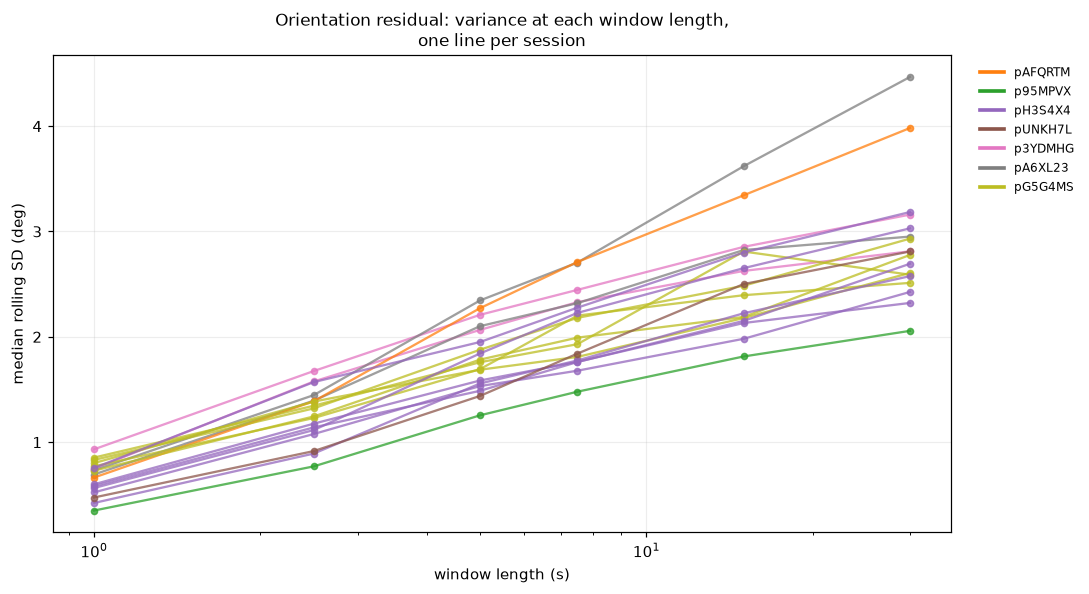

In [10]:
TERM_WINDOWS_S = [1.0, 2.5, 5.0, 7.5, 15.0, 30.0]


def variance_term_structure(t, v, windows_s=TERM_WINDOWS_S, hz=SAMPLE_HZ):
    out = {}
    s = pd.Series(v)
    for w in windows_s:
        n = max(3, int(round(w * hz)))
        roll_std = s.rolling(n, min_periods=max(3, n // 3)).std()
        out[w] = float(np.nanmedian(roll_std))
    return out


rows = []
for sid in _clean_sids:
    sess = raw.loc[raw['sessionId'] == sid]
    _, resid = orientation_residual(sess)
    if len(resid) < 200:
        continue
    ts = variance_term_structure(None, resid)
    rows.append({'session': SESSION_LABEL[sid], 'p': sess['participantId'].iloc[0], **ts})
term_orient = pd.DataFrame(rows).set_index('session')
print("Orientation-residual variance at each window length (deg):")
print(term_orient.round(2).to_string())


def plot_term_structure(term_df, title, ylabel):
    fig, ax = plt.subplots(figsize=(10, 5.5))
    for session, row in term_df.iterrows():
        p = row['p']
        y = [row[w] for w in TERM_WINDOWS_S]
        ax.plot(TERM_WINDOWS_S, y, 'o-', color=pcolor(p), alpha=0.75, markersize=4,
                label=session if session == term_df.index[0] else None)
    ax.set_xscale('log'); ax.set_xlabel("window length (s)"); ax.set_ylabel(ylabel)
    ax.set_title(title)
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS
              if p in term_df['p'].values]
    ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=8)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_term_structure(term_orient, "Orientation residual: variance at each window length,\n"
                                 "one line per session", "median rolling SD (deg)")

Motion-jerk variance at each window length:
                  p    1.0    2.5    5.0    7.5   15.0   30.0
session                                                      
p3YDMHG s1  p3YDMHG  2.625  3.133  3.256  3.281  3.279  3.319
p3YDMHG s2  p3YDMHG  2.178  2.425  2.559  2.716  2.758  2.741
p95MPVX s1  p95MPVX  2.345  2.557  2.719  2.821  2.842  2.902
pA6XL23 s1  pA6XL23  2.843  3.461  3.843  3.866  4.410  4.743
pA6XL23 s2  pA6XL23  4.102  4.447  4.663  4.961  6.137  6.726
pAFQRTM s1  pAFQRTM  3.554  3.946  4.390  4.536  4.895  5.111
pG5G4MS s1  pG5G4MS  4.700  5.228  5.781  5.890  6.164  6.161
pG5G4MS s2  pG5G4MS  4.930  5.208  5.567  5.845  5.634  5.706
pG5G4MS s3  pG5G4MS  4.520  5.212  5.571  5.707  5.831  6.215
pG5G4MS s4  pG5G4MS  5.218  6.005  6.748  6.979  6.675  6.747
pG5G4MS s5  pG5G4MS  4.871  5.584  5.617  5.579  5.747  5.652
pH3S4X4 s1  pH3S4X4  2.417  2.608  2.779  2.821  2.815  2.861
pH3S4X4 s2  pH3S4X4  2.617  2.771  2.873  2.933  3.091  3.096
pH3S4X4 s3  pH3S4X4  3.148

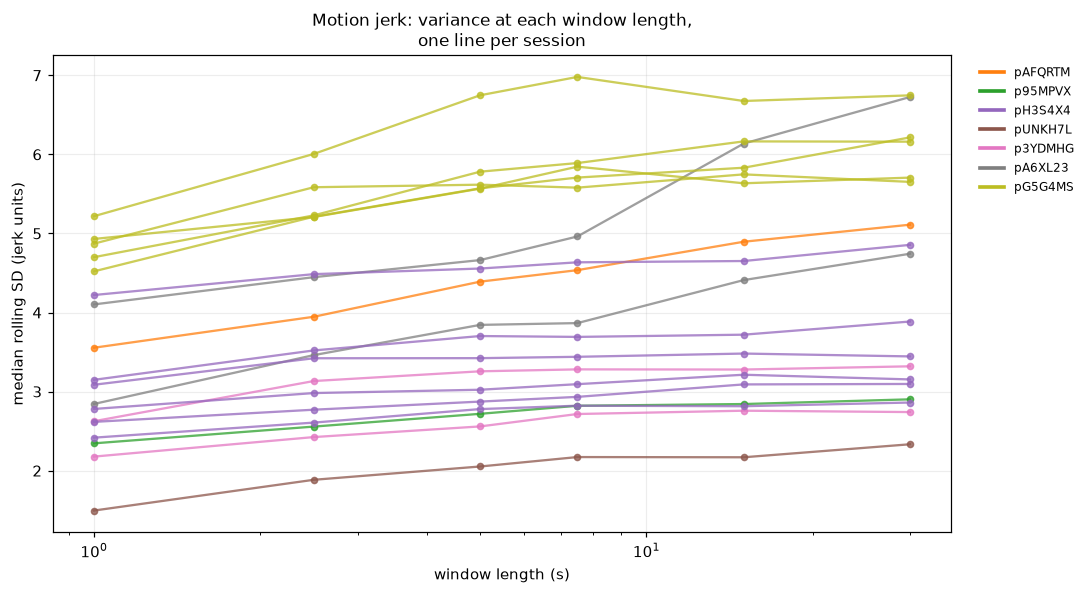

In [11]:
rows = []
for sid in _clean_sids:
    sess = raw.loc[raw['sessionId'] == sid]
    _, jerk = motion_jerk(sess)
    if len(jerk) < 200:
        continue
    ts = variance_term_structure(None, jerk)
    rows.append({'session': SESSION_LABEL[sid], 'p': sess['participantId'].iloc[0], **ts})
term_motion = pd.DataFrame(rows).set_index('session')
print("Motion-jerk variance at each window length:")
print(term_motion.round(3).to_string())
plot_term_structure(term_motion, "Motion jerk: variance at each window length,\n"
                                 "one line per session", "median rolling SD (jerk units)")

## 6. Mean-reversion speed, with its own self-consistency check

How fast does a perturbed hand snap back to its resting position? Fit the residual as a
simple AR(1) process — each reading predicted from the previous one by a coefficient phi —
and convert phi into a half-life in seconds. A short half-life means a "snappy" grip that
settles quickly; a long one means a looser, more drifting hold.

This metric was checked directly against the concern that matters most in this notebook:
does it agree with itself? Two tests, both shown below rather than asserted:

1. **Within-person, across sessions** — the standard replication check used throughout.
2. **Split-half, within one session** — does the first half of a session agree with the
   second half? A session containing a genuine event (a reposition, a sensor dropout) will
   disagree with itself here even when the underlying metric is sound elsewhere, and that
   needs to be visible rather than averaged away.

   session  halflife_s  first_half_s  second_half_s  split_half_gap  has_gap_or_singularity
p3M6E7Z s1        4.43          4.95           3.86            1.10                    True
p3YDMHG s1        3.60          4.43           3.00            1.43                   False
p3YDMHG s2        4.03          5.77           3.14            2.63                   False
p95MPVX s1        3.53          3.38           3.64            0.26                   False
p95MPVX s2        1.35          0.60          18.97           18.37                    True
pA6XL23 s1        8.37         13.91           7.08            6.83                   False
pA6XL23 s2        1.55          1.39           1.74            0.35                   False
pAFQRTM s1        2.38          6.65           2.01            4.63                   False
pG5G4MS s1        1.59          1.78           1.36            0.42                   False
pG5G4MS s2        1.95          2.81           1.37            1.44             

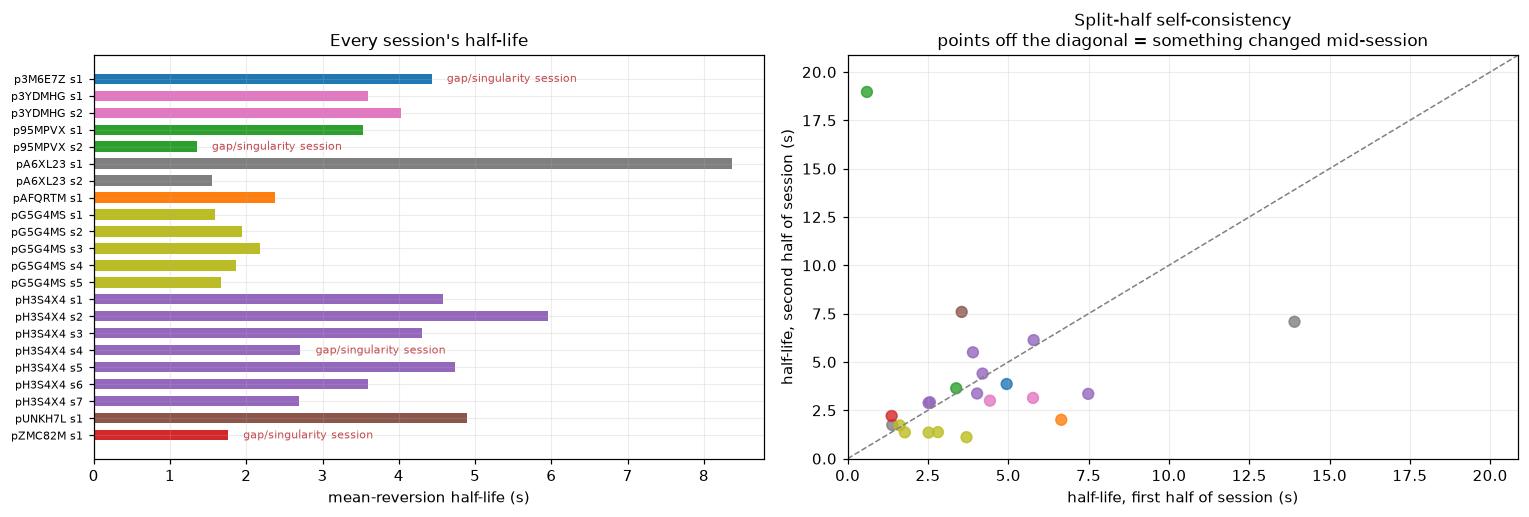

In [12]:
def ar1_halflife(resid, hz=SAMPLE_HZ):
    x = resid[:-1]; y = resid[1:]
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 100:
        return np.nan, np.nan
    x, y = x[ok], y[ok]
    phi = float(np.dot(x, y) / np.dot(x, x))
    phi = min(max(phi, 1e-4), 0.9999)
    return phi, (np.log(0.5) / np.log(phi)) / hz


rows = []
for sid in SESSION_ORDER:
    sess = raw.loc[raw['sessionId'] == sid]
    _, resid = orientation_residual(sess)
    if len(resid) < 600:
        continue
    phi, hl = ar1_halflife(resid)
    mid = len(resid) // 2
    _, hl1 = ar1_halflife(resid[:mid])
    _, hl2 = ar1_halflife(resid[mid:])
    rows.append({'p': sess['participantId'].iloc[0], 'session': SESSION_LABEL[sid],
                 'halflife_s': round(hl, 2), 'first_half_s': round(hl1, 2),
                 'second_half_s': round(hl2, 2),
                 'split_half_gap': round(abs(hl1 - hl2), 2),
                 'has_gap_or_singularity': sid not in _clean_sids})
hl_df = pd.DataFrame(rows)
print(hl_df.drop(columns='p').to_string(index=False))

print()
print("within-person replication (sessions with small split-half gap only):")
reliable = hl_df.loc[hl_df['split_half_gap'] < hl_df['split_half_gap'].median()]
for p, g in hl_df.groupby('p'):
    if len(g) > 1:
        print(f"  {p}: half-life = {g['halflife_s'].tolist()}  "
              f"(split-half gap per session: {g['split_half_gap'].tolist()})")


def plot_halflife(hl_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    ax = axes[0]
    order = hl_df.sort_values(['p', 'session'])
    y = np.arange(len(order))
    ax.barh(y, order['halflife_s'], color=[pcolor(p) for p in order['p']], height=0.6)
    for i, flagged in enumerate(order['has_gap_or_singularity']):
        if flagged:
            ax.text(order['halflife_s'].iloc[i] + 0.2, i, 'gap/singularity session',
                    va='center', fontsize=7, color='#c44e52')
    ax.set_yticks(y); ax.set_yticklabels(order['session'], fontsize=7.5); ax.invert_yaxis()
    ax.set_xlabel("mean-reversion half-life (s)")
    ax.set_title("Every session's half-life")

    ax = axes[1]
    ax.scatter(hl_df['first_half_s'], hl_df['second_half_s'],
              c=[pcolor(p) for p in hl_df['p']], s=50, alpha=0.8)
    lims = [0, max(hl_df['first_half_s'].max(), hl_df['second_half_s'].max()) * 1.1]
    ax.plot(lims, lims, color='0.5', ls='--', lw=1)
    ax.set_xlim(*lims); ax.set_ylim(*lims)
    ax.set_xlabel("half-life, first half of session (s)")
    ax.set_ylabel("half-life, second half of session (s)")
    ax.set_title("Split-half self-consistency\npoints off the diagonal = something changed mid-session")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_halflife(hl_df)

## 7. Volatility clustering

A question nobody has asked yet with this data: does shakiness come in bursts, or is each
moment of movement independent of the last? If bursts cluster in time, the *squared*
motion signal should be autocorrelated even when the raw signal itself isn't — this is
precisely the ARCH effect in financial returns, where calm and turbulent periods cluster
even though the direction of each individual return is unpredictable.

Autocorrelation of squared motion magnitude (lag in samples @ 20Hz):
   session  acf_lag1  acf_lag5
p3YDMHG s1     0.350     0.103
p3YDMHG s2     0.271     0.140
p95MPVX s1     0.472     0.400
pA6XL23 s1     0.281     0.105
pA6XL23 s2     0.405     0.048
pAFQRTM s1     0.597     0.292
pG5G4MS s1     0.379     0.042
pG5G4MS s2     0.431     0.350
pG5G4MS s3     0.311     0.134
pG5G4MS s4     0.647     0.028
pG5G4MS s5     0.302     0.082
pH3S4X4 s1     0.218     0.081
pH3S4X4 s2     0.119     0.061
pH3S4X4 s3     0.077     0.015
pH3S4X4 s5     0.195     0.086
pH3S4X4 s6     0.196     0.085
pH3S4X4 s7     0.149     0.020
pUNKH7L s1     0.549     0.439


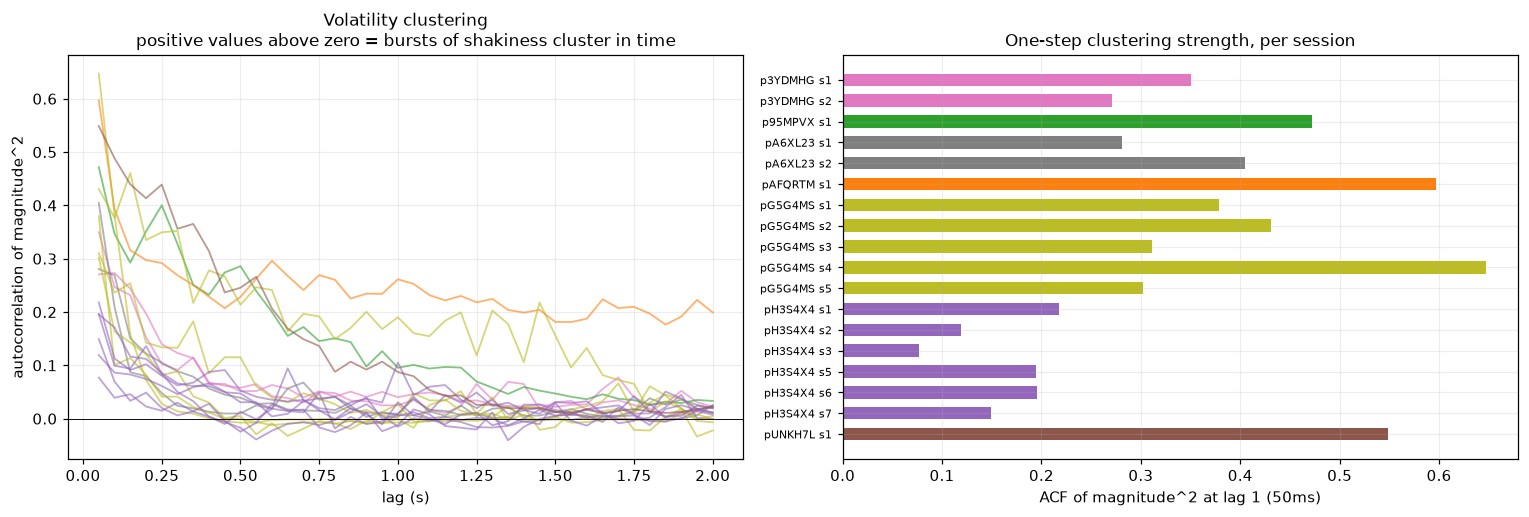

In [13]:
def acf(x, max_lag=40):
    x = x[np.isfinite(x)]
    x = x - x.mean()
    n = len(x)
    if n < max_lag * 2:
        return np.full(max_lag, np.nan)
    var = np.dot(x, x) / n
    out = np.empty(max_lag)
    for lag in range(1, max_lag + 1):
        out[lag - 1] = np.dot(x[:-lag], x[lag:]) / ((n - lag) * var) if var > 0 else np.nan
    return out


rows = []
acf_curves = {}
for sid in _clean_sids:
    sess = raw.loc[raw['sessionId'] == sid]
    _, mag = motion_magnitude(sess)
    if len(mag) < 500:
        continue
    sq = mag ** 2
    curve = acf(sq, max_lag=40)
    acf_curves[sid] = curve
    rows.append({'p': sess['participantId'].iloc[0], 'session': SESSION_LABEL[sid],
                 'acf_lag1': round(curve[0], 3), 'acf_lag5': round(curve[4], 3)})
clust = pd.DataFrame(rows)
print("Autocorrelation of squared motion magnitude (lag in samples @ 20Hz):")
print(clust.drop(columns='p').to_string(index=False))


def plot_clustering(acf_curves, clust_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    ax = axes[0]
    lags_s = np.arange(1, 41) / SAMPLE_HZ
    for sid, curve in acf_curves.items():
        p = raw.loc[raw['sessionId'] == sid, 'participantId'].iloc[0]
        ax.plot(lags_s, curve, color=pcolor(p), alpha=0.6, lw=1.2)
    ax.axhline(0, color='k', lw=0.6)
    ax.set_xlabel("lag (s)"); ax.set_ylabel("autocorrelation of magnitude^2")
    ax.set_title("Volatility clustering\npositive values above zero = bursts of shakiness cluster in time")

    ax = axes[1]
    order = clust_df.sort_values(['p', 'session'])
    y = np.arange(len(order))
    ax.barh(y, order['acf_lag1'], color=[pcolor(p) for p in order['p']], height=0.6)
    ax.set_yticks(y); ax.set_yticklabels(order['session'], fontsize=7.5); ax.invert_yaxis()
    ax.axvline(0, color='k', lw=0.6)
    ax.set_xlabel("ACF of magnitude^2 at lag 1 (50ms)")
    ax.set_title("One-step clustering strength, per session")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_clustering(acf_curves, clust)

## 8. Tail behaviour

Average wobble and extreme wobble are different questions. Someone might be steady on
average but produce occasional sharp spikes, or the reverse — evenly moderate throughout.
The ratio of an extreme percentile to the median separates these two, in a way that a
single variance number cannot.

95th-percentile / median ratio -- higher means occasional sharp spikes rather than
uniformly moderate movement:
   session  orient_tail_ratio  motion_tail_ratio
p3YDMHG s1               2.94               5.22
p3YDMHG s2               3.08               5.41
p95MPVX s1               3.64               5.59
pA6XL23 s1               4.78               8.32
pA6XL23 s2               3.38               7.74
pAFQRTM s1               7.47               7.61
pG5G4MS s1               4.52               4.65
pG5G4MS s2               4.14               4.94
pG5G4MS s3               4.01               4.65
pG5G4MS s4               3.56               5.16
pG5G4MS s5               3.39               4.69
pH3S4X4 s1               3.06               5.21
pH3S4X4 s2               3.15               5.12
pH3S4X4 s3               2.54               5.19
pH3S4X4 s5               3.61               4.82
pH3S4X4 s6               3.03               4.51
pH3S4X4 s7               3.32               4.34
pUNKH7

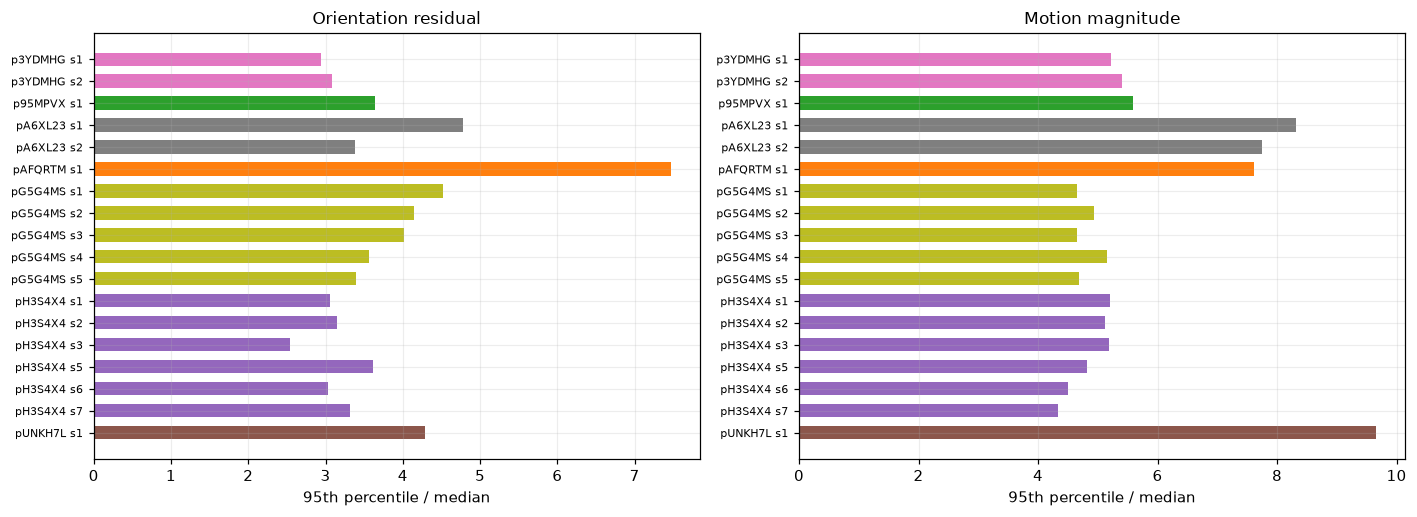

In [14]:
def tail_ratio(x, pct=95):
    x = np.abs(x[np.isfinite(x)])
    med = np.median(x)
    return float(np.percentile(x, pct) / med) if med > 0 else np.nan


rows = []
for sid in _clean_sids:
    sess = raw.loc[raw['sessionId'] == sid]
    _, resid = orientation_residual(sess)
    _, mag = motion_magnitude(sess)
    rows.append({'p': sess['participantId'].iloc[0], 'session': SESSION_LABEL[sid],
                 'orient_tail_ratio': round(tail_ratio(resid), 2) if len(resid) > 100 else np.nan,
                 'motion_tail_ratio': round(tail_ratio(mag - np.median(mag)), 2) if len(mag) > 100 else np.nan})
tail_df = pd.DataFrame(rows)
print("95th-percentile / median ratio -- higher means occasional sharp spikes rather than")
print("uniformly moderate movement:")
print(tail_df.drop(columns='p').to_string(index=False))


def plot_tail(tail_df):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    for ax, col, title in [(axes[0], 'orient_tail_ratio', 'Orientation residual'),
                           (axes[1], 'motion_tail_ratio', 'Motion magnitude')]:
        d = tail_df.dropna(subset=[col]).sort_values(['p', 'session'])
        y = np.arange(len(d))
        ax.barh(y, d[col], color=[pcolor(p) for p in d['p']], height=0.6)
        ax.set_yticks(y); ax.set_yticklabels(d['session'], fontsize=7.5); ax.invert_yaxis()
        ax.set_xlabel("95th percentile / median"); ax.set_title(title)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_tail(tail_df)

## 9. Cross-axis coupling

Does tilt and roll move together, or independently? A rolling correlation between how
fast beta is changing and how fast gamma is changing captures whether repositioning is a
single coordinated motion (both angles moving together) or whether the two axes wander
separately.

This one is flagged honestly rather than sold as clean: correlation between two changing
signals is not fully rotation-independent the way a magnitude is, since which physical
gesture maps to "beta changing" versus "gamma changing" still depends on how the phone is
held. Read it as a first look, not a settled measurement.

Median rolling correlation between beta-change and gamma-change (5s window):
   session  median_coupling
p3YDMHG s1             0.23
p3YDMHG s2             0.37
p95MPVX s1             0.60
pA6XL23 s1             0.20
pA6XL23 s2             0.13
pAFQRTM s1             0.01
pG5G4MS s1             0.42
pG5G4MS s2             0.53
pG5G4MS s3             0.36
pG5G4MS s4             0.42
pG5G4MS s5             0.43
pH3S4X4 s1             0.70
pH3S4X4 s2             0.69
pH3S4X4 s3             0.66
pH3S4X4 s5             0.67
pH3S4X4 s6             0.76
pH3S4X4 s7             0.63
pUNKH7L s1             0.64


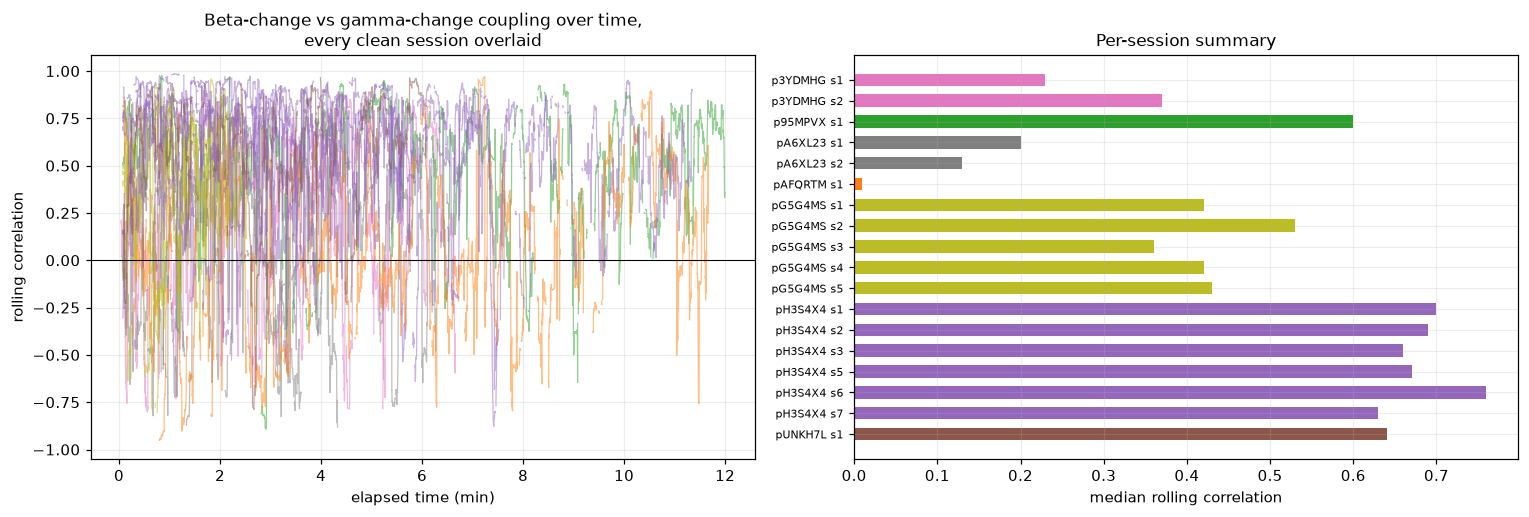

In [15]:
ROLL_WINDOW_S = 5.0


def rolling_cross_corr(sess, window_s=ROLL_WINDOW_S, hz=SAMPLE_HZ):
    t_b, b = orientation_series(sess, 'payload_beta')
    t_g, g = orientation_series(sess, 'payload_gamma')
    n = min(len(b), len(g))
    if n < 200:
        return np.array([]), np.array([])
    b, g = b[:n], g[:n]
    db = np.diff(b); dg = np.diff(g)
    win = max(10, int(round(window_s * hz)))
    s_b, s_g = pd.Series(db), pd.Series(dg)
    corr = s_b.rolling(win, min_periods=win // 2).corr(s_g).to_numpy()
    t = t_b[1:n]
    return t, corr


rows = []
demo_corr = {}
for sid in _clean_sids:
    sess = raw.loc[raw['sessionId'] == sid]
    t, corr = rolling_cross_corr(sess)
    if len(corr) < 50:
        continue
    demo_corr[sid] = (t, corr)
    rows.append({'p': sess['participantId'].iloc[0], 'session': SESSION_LABEL[sid],
                 'median_coupling': round(float(np.nanmedian(corr)), 2)})
coup_df = pd.DataFrame(rows)
print(f"Median rolling correlation between beta-change and gamma-change ({ROLL_WINDOW_S:.0f}s window):")
print(coup_df.drop(columns='p').to_string(index=False))


def plot_coupling(demo_corr, coup_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    ax = axes[0]
    for sid, (t, corr) in demo_corr.items():
        p = raw.loc[raw['sessionId'] == sid, 'participantId'].iloc[0]
        tb, cb = break_on_gaps(t, corr)
        ax.plot(tb / 60, cb, color=pcolor(p), alpha=0.5, lw=0.8)
    ax.axhline(0, color='k', lw=0.7)
    ax.set_xlabel("elapsed time (min)"); ax.set_ylabel("rolling correlation")
    ax.set_title("Beta-change vs gamma-change coupling over time,\nevery clean session overlaid")

    ax = axes[1]
    order = coup_df.sort_values(['p', 'session'])
    y = np.arange(len(order))
    ax.barh(y, order['median_coupling'], color=[pcolor(p) for p in order['p']], height=0.6)
    ax.set_yticks(y); ax.set_yticklabels(order['session'], fontsize=7.5); ax.invert_yaxis()
    ax.axvline(0, color='k', lw=0.6)
    ax.set_xlabel("median rolling correlation")
    ax.set_title("Per-session summary")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_coupling(demo_corr, coup_df)

## 10. Retained essentials: idle, availability, low-support flags

Two checks from the previous version still matter and aren't superseded by anything
above.

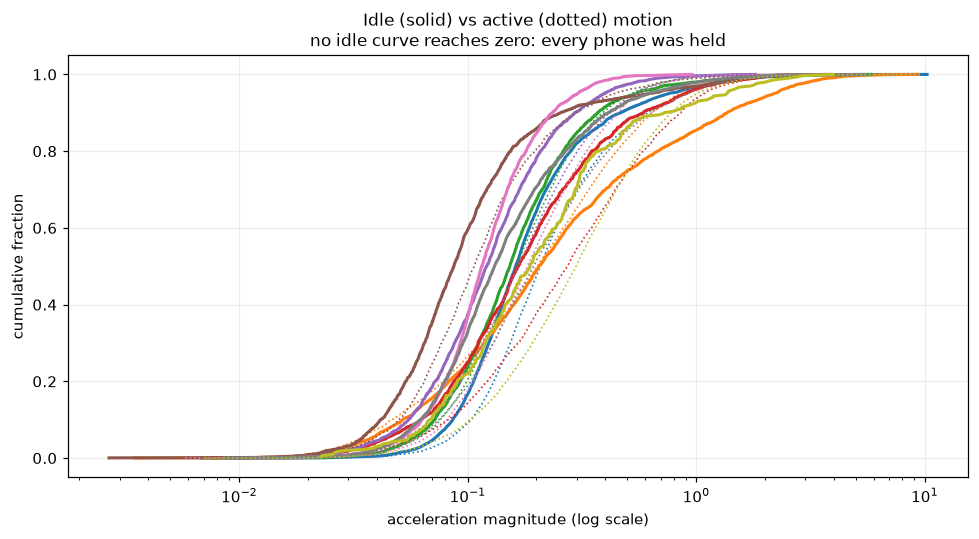

In [16]:
def idle_mask(sess, motion_t_ms):
    inter = np.sort(sess.loc[sess['kind'].isin(INTERACTION_KINDS), 'tRelMs'].to_numpy(float))
    if len(inter) == 0:
        return np.ones(len(motion_t_ms), bool)
    idx = np.searchsorted(inter, motion_t_ms)
    prev_gap = np.where(idx > 0, motion_t_ms - inter[np.clip(idx - 1, 0, len(inter) - 1)], np.inf)
    next_gap = np.where(idx < len(inter), inter[np.clip(idx, 0, len(inter) - 1)] - motion_t_ms, np.inf)
    return (prev_gap >= 1000.0) & (next_gap >= 1000.0)


def plot_idle_vs_active(raw_df):
    fig, ax = plt.subplots(figsize=(9, 5))
    for p in PARTICIPANTS:
        idle_v, act_v = [], []
        for sid, s in raw_df.loc[raw_df['participantId'] == p].groupby('sessionId'):
            mo = s.loc[s['kind'] == MOTION_KIND].sort_values('tRelMs')
            t = mo['tRelMs'].to_numpy(float)
            mag = np.sqrt(sum(pd.to_numeric(mo[c], errors='coerce').to_numpy(float) ** 2
                              for c in ACCEL_COLS))
            ok = np.isfinite(mag)
            if ok.sum() < 100:
                continue
            im = idle_mask(s, t[ok])
            idle_v.append(mag[ok][im]); act_v.append(mag[ok][~im])
        for arr, ls, lw in ((idle_v, '-', 2.0), (act_v, ':', 1.1)):
            arr = [a for a in arr if len(a)]
            if not arr:
                continue
            v = np.concatenate(arr); v = v[v > 0]
            if len(v) < 50:
                continue
            ax.plot(np.sort(v), np.arange(1, len(v) + 1) / len(v), color=pcolor(p), ls=ls, lw=lw)
    ax.set_xscale('log'); ax.set_xlabel("acceleration magnitude (log scale)")
    ax.set_ylabel("cumulative fraction")
    ax.set_title("Idle (solid) vs active (dotted) motion\nno idle curve reaches zero: every phone was held")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_idle_vs_active(raw)

In [17]:
MIN_IDLE_RUN = 60
LOW_SUPPORT_PCT = 3.0


def idle_runs(raw_df):
    rows = []
    for sid, s in raw_df.groupby('sessionId'):
        mo = s.loc[s['kind'] == MOTION_KIND].sort_values('tRelMs')
        t = mo['tRelMs'].to_numpy(float)
        if len(t) < 100:
            continue
        im = idle_mask(s, t)
        change = np.where(np.diff(im.astype(int)) != 0)[0] + 1
        for run in np.split(np.arange(len(t)), change):
            if len(run) < MIN_IDLE_RUN or not im[run[0]]:
                continue
            rows.append({'participantId': s['participantId'].iloc[0], 'sessionId': sid,
                         'duration_s': (t[run[-1]] - t[run[0]]) / 1000.0})
    return pd.DataFrame(rows)


runs = idle_runs(raw)
avail = (runs.groupby('participantId').agg(idle_epochs=('duration_s', 'size'),
                                           idle_seconds=('duration_s', 'sum'))
         .reindex(PARTICIPANTS).fillna(0))
avail['session_minutes'] = (session_index.groupby('participantId')['duration_s'].sum()
                            .reindex(PARTICIPANTS) / 60).round(1)
avail['idle_pct'] = (avail['idle_seconds'] / (avail['session_minutes'] * 60) * 100).round(1)
print(avail.astype({'idle_epochs': int}).to_string())
_low = avail.loc[(avail['idle_epochs'] > 0) & (avail['idle_pct'] < LOW_SUPPORT_PCT)]
if len(_low):
    print(f"\nlow support (present but under {LOW_SUPPORT_PCT:.0f}% idle): {', '.join(_low.index)}")
_zero = avail.loc[avail['idle_epochs'] == 0]
if len(_zero):
    print(f"cannot be measured at all (zero idle epochs): {', '.join(_zero.index)}")

               idle_epochs  idle_seconds  session_minutes  idle_pct
participantId                                                      
p3M6E7Z                 32       281.233             15.9      29.5
pAFQRTM                 13       102.350             11.7      14.6
p95MPVX                 13       126.448             20.3      10.4
pZMC82M                  8       109.319              7.3      25.0
pH3S4X4                  6        27.651             49.0       0.9
pUNKH7L                 12        69.884              6.0      19.4
p3YDMHG                 13        59.717             11.9       8.4
pA6XL23                 17       113.782             10.6      17.9
pG5G4MS                  1         3.617             11.7       0.5

low support (present but under 3% idle): pH3S4X4, pG5G4MS


## 11. Data-quality notes

All established in the previous version and carried over unchanged:

- **`alpha` wraps in every session**; averaging it naively is wrong by up to 176 degrees.
  **`beta` wraps in one session** (the participant with the widest posture range). Every
  computation in this notebook that touches beta unwraps it first.
- **Beta approaching +-90 degrees breaks gamma** (the Euler-angle singularity). One session
  in this cohort sits there and is excluded from every derived-metric computation above via
  the `_clean_sids` filter.
- **Orientation and motion both sample at 20Hz**, putting hand tremor (8-12Hz) at or past
  the Nyquist limit. Anything in that band in Section 7's clustering plot is a coarse
  indicator, not a precise measurement.
- **Sensor dropouts up to 60 seconds** occur in three sessions. These are excluded from the
  `_clean_sids` set used throughout Sections 4-9, and their lines break rather than draw a
  straight line across the gap wherever they do appear (Section 2).

## 12. Per-participant summary

In [18]:
summary = pd.DataFrame(index=PARTICIPANTS)
summary['sessions'] = session_index.groupby('participantId').size().reindex(PARTICIPANTS)
summary['clean_sessions'] = pd.Series(
    {p: sum(1 for sid in session_index.loc[session_index.participantId == p, 'sessionId']
           if sid in _clean_sids) for p in PARTICIPANTS})
summary['halflife_median_s'] = hl_df.groupby('p')['halflife_s'].median().reindex(PARTICIPANTS)
summary['acf_lag1_median'] = clust.groupby('p')['acf_lag1'].median().reindex(PARTICIPANTS)
summary['orient_tail_ratio_median'] = tail_df.groupby('p')['orient_tail_ratio'].median().reindex(PARTICIPANTS)
summary['motion_tail_ratio_median'] = tail_df.groupby('p')['motion_tail_ratio'].median().reindex(PARTICIPANTS)
summary['coupling_median'] = coup_df.groupby('p')['median_coupling'].median().reindex(PARTICIPANTS)
summary['idle_pct'] = avail['idle_pct']

print("Blank cells mean the quantity could not be computed for that person (usually because")
print("every one of their sessions was excluded as gap-affected or singular).\n")
print(summary.round(2).to_string())

Blank cells mean the quantity could not be computed for that person (usually because
every one of their sessions was excluded as gap-affected or singular).

         sessions  clean_sessions  halflife_median_s  acf_lag1_median  orient_tail_ratio_median  motion_tail_ratio_median  coupling_median  idle_pct
p3M6E7Z         1               0               4.43              NaN                       NaN                       NaN              NaN      29.5
pAFQRTM         1               1               2.38             0.60                      7.47                      7.61             0.01      14.6
p95MPVX         2               1               2.44             0.47                      3.64                      5.59             0.60      10.4
pZMC82M         1               0               1.76              NaN                       NaN                       NaN              NaN      25.0
pH3S4X4         7               6               4.30             0.17                      3.10   

## 13. Open questions

- **Mean-reversion half-life is the strongest lead so far**, replicating for 3-4 of 5
  multi-session participants, with the disagreement in the others explained by known
  in-session events rather than the metric itself. It has not been tested against a
  device-confound control, and there still aren't enough sessions per person to call it a
  settled trait.
- **Volatility clustering and tail behaviour are newly measured here** and have not yet
  been checked for within-person replication the way mean-reversion has. That check is the
  natural next step before either is trusted.
- **Cross-axis coupling is the most speculative measure in this notebook** — flagged
  in Section 9 as only partially rotation-independent, and worth treating as an early look
  rather than a candidate feature until that's resolved.
- **The multi-scale variance term structure replaces the earlier single-cutoff spectral
  ratio**, but whether its *shape* (not just its level) differs meaningfully between people
  hasn't been examined — this notebook shows the curves, not what to read from their shape.
- **The rotation-invariance finding in Section 3 suggests every magnitude-based feature in
  this notebook should eventually be re-examined stratified by broad posture category**,
  not assumed independent of it by default.
- **Every participant here is still on their own device.** Nothing in this notebook
  resolves whether any of these derived dynamics describe the person or the phone.